In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern", "Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [4]:
# Average latencies (example values in milliseconds)
#  the between stage time includes queueing
# vortex_avg_
# sys_name="Vortex"
sys_name="Typhoon"
# avg send rate 32
latencies = {
    "d-A": 0.47,
    "d-B": 1.98,
    "stepA": 14.63,
    "stepB": 35.57,
    "A-C": 24.33,
    "B-C": 1.87,
    "stepC": 4.79,
    "C-D": 1.69,
    "stepD": 24.74
}
# # avg send rate 85
# latencies = {
#     "d-A":4.661,
#     "d-B":1.686,
#     "stepA": 18.993,
#     "stepB": 30.854,
#     "A-C": 7.629,
#     "B-C": 4.829,
#     "stepC": 5.410,
#     "C-D": 1.329,
#     "stepD": 24.536
# }



# sys_name="Ray Serve"
# # send rate 32
# latencies = {
#     "d-A": 11.1,
#     "d-B": 13.1,
#     "stepA": 9.5,
#     "stepB": 31.4,
#     "A-C": 34.4,
#     "B-C": 10.3,
#     "stepC": 4.7,
#     "C-D": 7.2,
#     "stepD": 33.1
# }
# # send rate 85
# latencies = {
#     "d-A": 15.2,
#     "d-B": 29.3,
#     "stepA": 13.2,
#     "stepB": 48.1,
#     "A-C": 65.2,
#     "B-C": 16.1,
#     "stepC": 11.1,
#     "C-D": 30.7,
#     "stepD": 63.4
# }

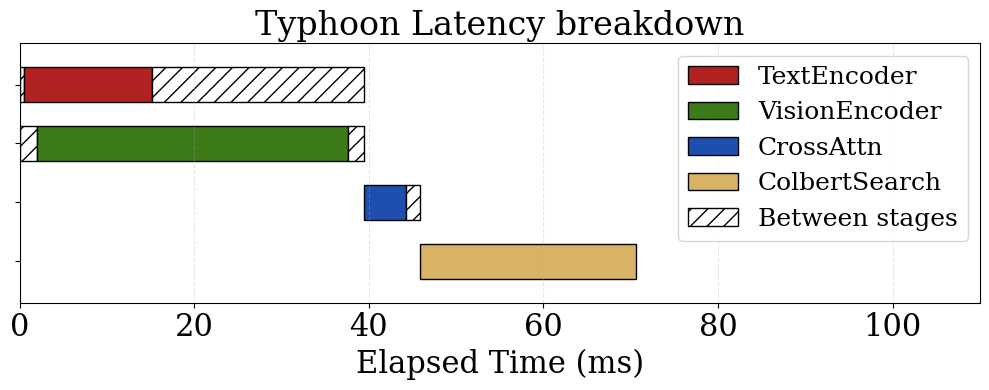

In [5]:
# Define execution lines
line1 = [
    ("d-A", 0),
    ("stepA", latencies["d-A"]),
    ("A-C", latencies["d-A"] + latencies["stepA"])
]
line2 = [
    ("d-B", 0),
    ("stepB", latencies["d-B"]),
    ("B-C", latencies["d-B"] + latencies["stepB"])
]

# Determine when stepC can start (after both A->C and B->C are complete)
stepC_start = max(
    latencies["d-A"] + latencies["stepA"] + latencies["A-C"],
    latencies["d-B"] + latencies["stepB"] + latencies["B-C"]
)

line3 = [
    ("stepC", stepC_start),
    ("C-D", stepC_start + latencies["stepC"]),
    ("stepD", stepC_start + latencies["stepC"] + latencies["C-D"])
]

# Assign distinct colors to steps and hatch for transfers
color_map = {
    "d-A": "white",
    "d-B": "white",
    "A-C": "white",
    "B-C": "white",
    "C-D": "white",
    "stepA": "#B22222",  # firebrick — a strong, classic deep red with minimal pink
    "stepB": "#3C7A1A",  # bold green
    "stepC": "#1E4FAE",  # vivid blue
    "stepD": "#d8b365"      # muted golden yellow
}

# color_map = {
#     "stepA": "#b2182b",     # deep red
#     "stepB": "#1a9850",     # forest green
#     "stepCD": "#2166ac",    # rich blue
#     "stepE": 
# }

hatch_map = {
    "d-A": "//",
    "d-B": "//",
    "A-C": "//",
    "B-C": "//",
    "C-D": "//",
    "stepA": None,
    "stepB": None,
    "stepC": None,
    "stepD": None
}

# Y-axis level mapping
y_levels = {
    "d-A": 4,
    "stepA": 4,
    "A-C": 4,
    "d-B": 3,
    "stepB": 3,
    "B-C": 3,
    "stepC": 2,
    "C-D": 2,
    "stepD": 1
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Function to draw bars with optional hatching
def plot_bars_custom(line):
    for step, start_time in line:
        duration = latencies[step]
        y_level = y_levels[step]
        rect = patches.Rectangle(
            (start_time, y_level - 0.3), duration, 0.6,
            edgecolor='black',
            facecolor=color_map[step],
            hatch=hatch_map[step] if hatch_map[step] else '',
            label=step
        )
        ax.add_patch(rect)

        # Optional: add duration labels on bars
        # ax.text(start_time + duration / 2, y_level, f"{duration:.1f}",
        #         ha='center', va='center', fontsize=8, color='black')

# Plot all lines
plot_bars_custom(line1)
plot_bars_custom(line2)
plot_bars_custom(line3)

# Create unique legend handles
legend_keys = set()
handles = []
for step in color_map:
    color = color_map[step]
    hatch = hatch_map[step] if hatch_map[step] else ''
    key = (color, hatch)
    if key not in legend_keys:
        legend_keys.add(key)
        patch = patches.Patch(
            facecolor=color, edgecolor='black',
            hatch=hatch, label=step
        )
        handles.append(patch)

# Set axis properties
ax.set_yticks([1, 2, 3, 4])
# ax.set_yticklabels(['D', 'C', 'B', 'A'])
ax.tick_params(axis='y', labelleft=False)
# Set x-axis tick label size
ax.tick_params(axis='x', labelsize=22)

# Set y-axis tick label size
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Elapsed Time (ms)", fontsize=22)
ax.set_title(f"{sys_name} Latency breakdown", fontsize=24)
ax.set_xlim(0, 110)
ax.set_ylim(0.3, 4.7)
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Add legend
# ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Component names", fontsize=10)
# Create legend handles: step colors + "Between stages" hatch
handles = []

# Track seen labels to avoid duplicates
seen_labels = set()
step_labels = {
    "stepA": "TextEncoder",
    "stepB": "VisionEncoder",
    "stepC": "CrossAttn",
    "stepD": "ColbertSearch"
}
# Add step runtime legend entries (colored, no hatch)
for step in ["stepA", "stepB", "stepC", "stepD"]:
    label = step_labels[step]
    color = color_map[step]
    if label not in seen_labels:
        patch = patches.Patch(facecolor=color, edgecolor='black', label=label)
        handles.append(patch)
        seen_labels.add(label)

# Add a single entry for all hatched (transfer) segments
# handles = ["textEnc", "VisEnc", "CrossAtn", "Search"]
transfer_patch = patches.Patch(facecolor='white', edgecolor='black', hatch='//', label='Between stages')
handles.append(transfer_patch)


ax.legend(
    handles=handles,
    loc='upper right',           # standard corner inside the plot
    # title="Component names",
    # title_fontsize=15,
    fontsize=18,
    frameon=True                # optional: show box around legend
)
# Save and display
plt.tight_layout()
plt.savefig(f"{sys_name}_latency_breakdown.pdf", dpi=600, bbox_inches='tight')
plt.show()


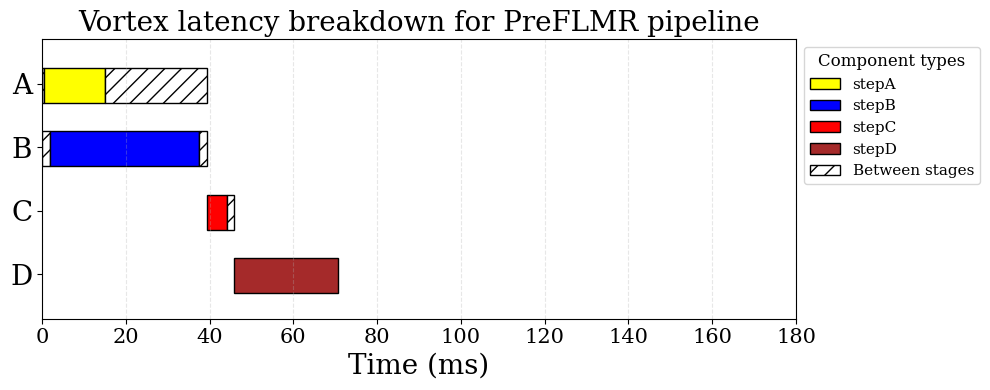

In [5]:
# Define execution lines
line1 = [
    ("d-A", 0),
    ("stepA", latencies["d-A"]),
    ("A-C", latencies["d-A"] + latencies["stepA"])
]
line2 = [
    ("d-B", 0),
    ("stepB", latencies["d-B"]),
    ("B-C", latencies["d-B"] + latencies["stepB"])
]

# Determine when stepC can start (after both A->C and B->C are complete)
stepC_start = max(
    latencies["d-A"] + latencies["stepA"] + latencies["A-C"],
    latencies["d-B"] + latencies["stepB"] + latencies["B-C"]
)

line3 = [
    ("stepC", stepC_start),
    ("C-D", stepC_start + latencies["stepC"]),
    ("stepD", stepC_start + latencies["stepC"] + latencies["C-D"])
]

# Assign distinct colors to steps and hatch for transfers
color_map = {
    "d-A": "white",
    "d-B": "white",
    "A-C": "white",
    "B-C": "white",
    "C-D": "white",
    "stepA": "yellow",
    "stepB": "blue",
    "stepC": "red",
    "stepD": "brown"
}

hatch_map = {
    "d-A": "//",
    "d-B": "//",
    "A-C": "//",
    "B-C": "//",
    "C-D": "//",
    "stepA": None,
    "stepB": None,
    "stepC": None,
    "stepD": None
}

# Y-axis level mapping
y_levels = {
    "d-A": 4,
    "stepA": 4,
    "A-C": 4,
    "d-B": 3,
    "stepB": 3,
    "B-C": 3,
    "stepC": 2,
    "C-D": 2,
    "stepD": 1
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Function to draw bars with optional hatching
def plot_bars_custom(line):
    for step, start_time in line:
        duration = latencies[step]
        y_level = y_levels[step]
        rect = patches.Rectangle(
            (start_time, y_level - 0.3), duration, 0.55,
            edgecolor='black',
            facecolor=color_map[step],
            hatch=hatch_map[step] if hatch_map[step] else '',
            label=step
        )
        ax.add_patch(rect)

        # Optional: add duration labels on bars
        # ax.text(start_time + duration / 2, y_level, f"{duration:.1f}",
        #         ha='center', va='center', fontsize=8, color='black')

# Plot all lines
plot_bars_custom(line1)
plot_bars_custom(line2)
plot_bars_custom(line3)

# Create unique legend handles
legend_keys = set()
handles = []
for step in color_map:
    color = color_map[step]
    hatch = hatch_map[step] if hatch_map[step] else ''
    key = (color, hatch)
    if key not in legend_keys:
        legend_keys.add(key)
        patch = patches.Patch(
            facecolor=color, edgecolor='black',
            hatch=hatch, label=step
        )
        handles.append(patch)

# Set axis properties
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['D', 'C', 'B', 'A'])
# Set x-axis tick label size
ax.tick_params(axis='x', labelsize=15)

# Set y-axis tick label size
ax.tick_params(axis='y', labelsize=20)

ax.set_xlabel("Time (ms)", fontsize=20)
ax.set_title(f"{sys_name} latency breakdown for PreFLMR pipeline", fontsize=20)
ax.set_xlim(0, 180)
ax.set_ylim(0.3, 4.7)
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Add legend
# ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Component names", fontsize=10)
# Create legend handles: step colors + "Between stages" hatch
handles = []

# Track seen labels to avoid duplicates
seen_labels = set()

# Add step runtime legend entries (colored, no hatch)
for step in ["stepA", "stepB", "stepC", "stepD"]:
    label = step
    color = color_map[step]
    if label not in seen_labels:
        patch = patches.Patch(facecolor=color, edgecolor='black', label=label)
        handles.append(patch)
        seen_labels.add(label)

# Add a single entry for all hatched (transfer) segments
transfer_patch = patches.Patch(facecolor='white', edgecolor='black', hatch='//', label='Between stages')
handles.append(transfer_patch)
ax.legend(handles=handles, bbox_to_anchor=(1, 1), loc='upper left',
          title="Component types", title_fontsize=12, fontsize=11)
# Save and display
plt.tight_layout()
plt.savefig(f"{sys_name}_latency_breakdown.pdf", dpi=600, bbox_inches='tight')
plt.show()

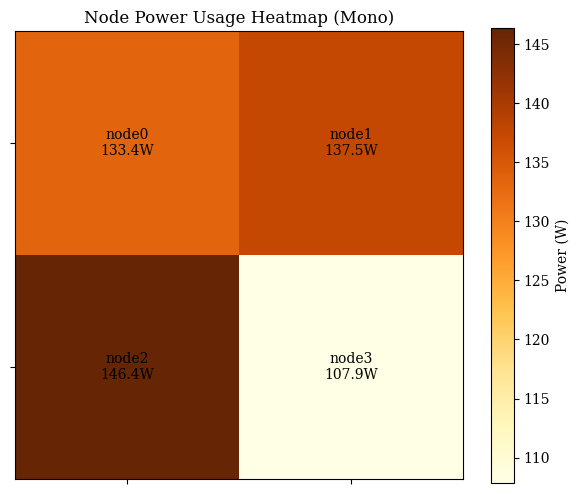

In [6]:
# Define power usage for each node (replace with actual values as needed)
deployment_type = "Mono"
power_usage = {
    "node0": 133.38,
    "node1": 137.50,
    "node2": 146.40,
    "node3": 107.87
}

# power_usage = {
#     "node0": 128.5,
#     "node1": 130.2,
#     "node2": 131.7,
#     "node3": 129.4
# }

power_grid = np.array([
    [power_usage["node0"], power_usage["node1"]],
    [power_usage["node2"], power_usage["node3"]]
])

# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 5))
heatmap = ax.imshow(power_grid, cmap='YlOrBr', interpolation='nearest')

# Annotate each cell with node name and power usage
node_labels = [["node0", "node1"], ["node2", "node3"]]
for i in range(2):
    for j in range(2):
        label = f"{node_labels[i][j]}\n{power_grid[i, j]:.1f}W"
        ax.text(j, i, label, ha='center', va='center', color='black', fontsize=10)

# Remove axis labels and ticks
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([])
ax.set_yticklabels([])

# Add title and colorbar
ax.set_title(f"Node Power Usage Heatmap ({deployment_type})")
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Power (W)")

# Final layout
plt.tight_layout()
plt.savefig(f"{sys_name}_power_usage_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5m/0xdx3r_57y541knfgfck0b3m0000gn/T/ipykernel_56875/694306056.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


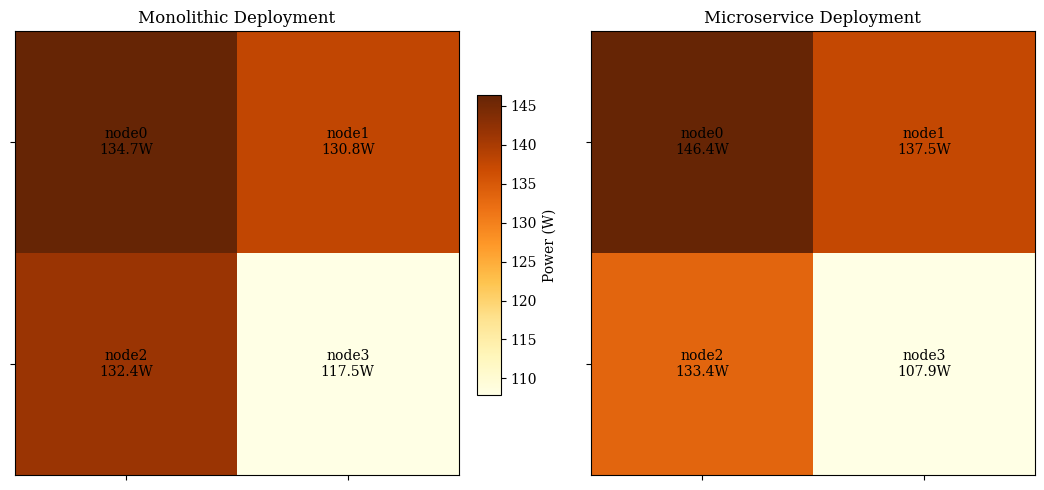

In [7]:
# Example power usage for two deployment strategies
monolithic_power = {
    "node0": 134.66,
    "node1": 130.81,
    "node2": 132.39,
    "node3": 117.48
}

microservice_power = {
    "node0": 146.40,
    "node1": 137.50,
    "node2": 133.38,
    "node3": 107.87
}

# Arrange power data into 2x2 grids
monolithic_grid = np.array([
    [monolithic_power["node0"], monolithic_power["node1"]],
    [monolithic_power["node2"], monolithic_power["node3"]]
])

microservice_grid = np.array([
    [microservice_power["node0"], microservice_power["node1"]],
    [microservice_power["node2"], microservice_power["node3"]]
])

# Node labels for annotations
node_labels = [["node0", "node1"], ["node2", "node3"]]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Titles and data for each subplot
titles = ["Monolithic Deployment", "Microservice Deployment"]
grids = [monolithic_grid, microservice_grid]

# Draw each heatmap
for idx, ax in enumerate(axes):
    heatmap = ax.imshow(grids[idx], cmap='YlOrBr', interpolation='nearest')
    for i in range(2):
        for j in range(2):
            label = f"{node_labels[i][j]}\n{grids[idx][i, j]:.1f}W"
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(titles[idx])

# Shared vertical colorbar centered between the plots
# [left, bottom, width, height] coordinates
cbar_ax = fig.add_axes([0.46, 0.2, 0.02, 0.6])  # Adjust as needed
cbar = plt.colorbar(heatmap, cax=cbar_ax)
cbar.set_label("Power (W)")

# Layout and display
plt.tight_layout()
plt.savefig(f"deployment_power.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5m/0xdx3r_57y541knfgfck0b3m0000gn/T/ipykernel_56875/497682186.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


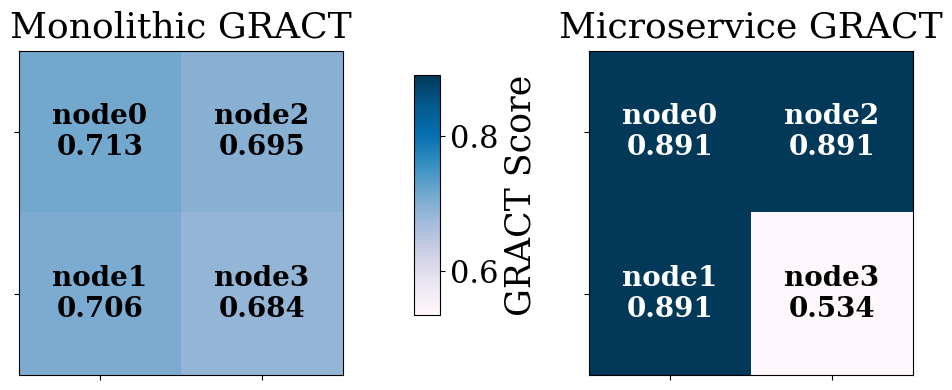

In [8]:
# GRACT values at high load (105 SR)
#  system throughput 98.53, latency med 401ms, 95% 529ms
monolithic_gract = {
    "node0": 0.713,
    "node1": 0.706,
    "node2": 0.695,
    "node3": 0.684
}

# # GRACT value at 105 SR for micro
# # system throughput 99qps, latency med 102ms, 95% 153ms
# microservice_gract = {
#     "node0": 0.866,
#     "node1": 0.862,
#     "node2": 0.860,
#     "node3": 0.450
# }

# GRACT value at high load (120 SR)
# system throughput 112.7qps, latency med 210ms, 95% 362ms
microservice_gract = {
    "node0": 0.891,
    "node1": 0.891,
    "node2": 0.891,
    "node3": 0.534
}


# Arrange into 2x2 grids
monolithic_gract_grid = np.array([
    [monolithic_gract["node0"], monolithic_gract["node2"]],
    [monolithic_gract["node1"], monolithic_gract["node3"]]
])

microservice_gract_grid = np.array([
    [microservice_gract["node0"], microservice_gract["node2"]],
    [microservice_gract["node1"], microservice_gract["node3"]]
])

# Combine all values for shared color scale
all_values = np.concatenate([monolithic_gract_grid.flatten(), microservice_gract_grid.flatten()])
vmin, vmax = np.min(all_values), np.max(all_values)

# Node labels
node_labels = [["node0", "node2"], ["node1", "node3"]]

# Set up the plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
titles = ["Monolithic GRACT", "Microservice GRACT"]
grids = [monolithic_gract_grid, microservice_gract_grid]

# Plot each heatmap
for idx, ax in enumerate(axes):
    grid = grids[idx]
    heatmap = ax.imshow(grid, cmap='PuBu', interpolation='nearest', vmin=vmin, vmax=vmax)

    # Annotate with adaptive text color and larger font
    for i in range(2):
        for j in range(2):
            val = grid[i, j]
            text_color = 'white' if val >= 0.8 else 'black'
            label = f"{node_labels[i][j]}\n{val:.3f}"
            ax.text(j, i, label, ha='center', va='center', color=text_color, fontsize=20, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(titles[idx], fontsize=26, pad=10)

# Add shared vertical colorbar between plots
cbar_ax = fig.add_axes([0.46, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = plt.colorbar(heatmap, cax=cbar_ax)
cbar.set_label("GRACT Score", fontsize=25)
cbar.ax.tick_params(labelsize=22)  
# Save and display
plt.tight_layout()
plt.savefig("deployment_gract_two.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5m/0xdx3r_57y541knfgfck0b3m0000gn/T/ipykernel_73108/3550515042.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0, 1, 1])


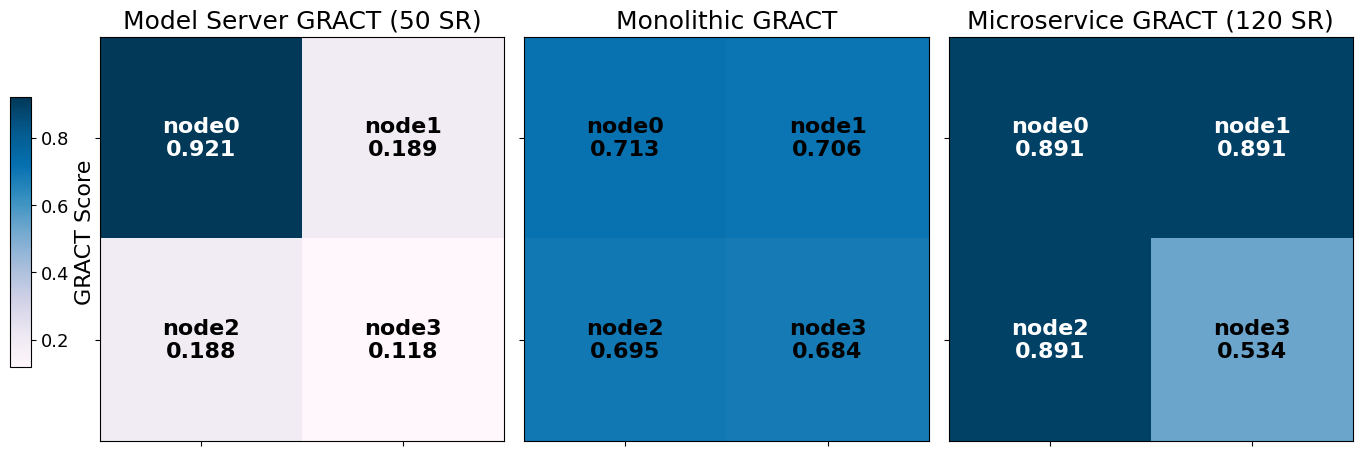

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# GRACT value at high load (50 SR)
# system throughput 43.4, latency med 2780ms, 95% 4814ms
modelserver_gract = {
    "node0": 0.921,
    "node1": 0.189,
    "node2": 0.188,
    "node3": 0.118
}

# GRACT values
monolithic_gract = {
    "node0": 0.713,
    "node1": 0.706,
    "node2": 0.695,
    "node3": 0.684
}

# GRACT value at high load (120 SR)
# system throughput 112.7qps, latency med 210ms, 95% 362ms
microservice_gract = {
    "node0": 0.891,
    "node1": 0.891,
    "node2": 0.891,
    "node3": 0.534
}

# Arrange into 2x2 grids
modelserver_gract_grid = np.array([
    [modelserver_gract["node0"], modelserver_gract["node1"]],
    [modelserver_gract["node2"], modelserver_gract["node3"]]
])

monolithic_gract_grid = np.array([
    [monolithic_gract["node0"], monolithic_gract["node1"]],
    [monolithic_gract["node2"], monolithic_gract["node3"]]
])

microservice_gract_grid = np.array([
    [microservice_gract["node0"], microservice_gract["node1"]],
    [microservice_gract["node2"], microservice_gract["node3"]]
])

# Combine all values for shared color scale
all_values = np.concatenate([
    modelserver_gract_grid.flatten(),
    monolithic_gract_grid.flatten(),
    microservice_gract_grid.flatten()
])
vmin, vmax = np.min(all_values), np.max(all_values)

# Node labels
node_labels = [["node0", "node1"], ["node2", "node3"]]

# Set up the plots with reduced width
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
titles = ["Model Server GRACT (50 SR)", "Monolithic GRACT", "Microservice GRACT (120 SR)"]
grids = [modelserver_gract_grid, monolithic_gract_grid, microservice_gract_grid]

# Plot each heatmap
for idx, ax in enumerate(axes):
    grid = grids[idx]
    heatmap = ax.imshow(grid, cmap='PuBu', interpolation='nearest', vmin=vmin, vmax=vmax)

    for i in range(2):
        for j in range(2):
            val = grid[i, j]
            text_color = 'white' if val >= 0.8 else 'black'
            label = f"{node_labels[i][j]}\n{val:.3f}"
            ax.text(j, i, label, ha='center', va='center', color=text_color, fontsize=16, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(titles[idx], fontsize=18)

# Reduce space between subplots
plt.subplots_adjust(wspace=0.2)

# Add shared colorbar on the left
cbar_ax = fig.add_axes([0.03, 0.2, 0.015, 0.6])
cbar = plt.colorbar(heatmap, cax=cbar_ax)
cbar.set_label("GRACT Score", fontsize=16)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout(rect=[0.08, 0, 1, 1])
plt.savefig("deployment_gract_three_modes_reordered.pdf", dpi=300, bbox_inches='tight')
plt.show()